# Activity: Build a K-means model 

## **Introduction**

K-means clustering is very effective when segmenting data and attempting to find patterns. Because clustering is used in a broad array of industries, becoming proficient in this process will help you expand your skillset in a widely applicable way.   

In this activity, you are a consultant for a scientific organization that works to support and sustain penguin colonies. You are tasked with helping other staff members learn more about penguins in order to achieve this mission. 

The data for this activity is in a spreadsheet that includes datapoints across a sample size of 345 penguins, such as species, island, and sex. Your will use a K-means clustering model to group this data and identify patterns that provide important insights about penguins.

**Note:** Because this lab uses a real dataset, this notebook will first require basic EDA, data cleaning, and other manipulations to prepare the data for modeling. 

## **Step 1: Imports** 


Import statements including `K-means`, `silhouette_score`, and `StandardScaler`.

In [1]:
# Import standard operational packages.
import numpy as np
import pandas as pd
# Important tools for modeling and evaluation.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
# Import visualization packages.

### YOUR CODE HERE ###
import matplotlib.pyplot as plt
import seaborn as sns

`Pandas` is used to load the penguins dataset, which is built into the `seaborn` library. The resulting `pandas` DataFrame is saved in a variable named `penguins`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Save the `pandas` DataFrame in variable `penguins`. 

### YOUR CODE HERE ###

penguins = pd.read_csv("penguins.csv")

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `load_dataset` function. 

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

The function is from seaborn (`sns`). It should be passed in the dataset name `'penguins'` as a string. 

</details>

Now, review the first 10 rows of data.


In [3]:
# Review the first 10 rows.

### YOUR CODE HERE ###
penguins.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `head()` method.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

By default, the method only returns five rows. To change this, specify how many rows `(n = )` you want.

</details>

## **Step 2: Data exploration** 

After loading the dataset, the next step is to prepare the data to be suitable for clustering. This includes: 

*   Exploring data
*   Checking for missing values
*   Encoding data 
*   Dropping a column
*   Scaling the features using `StandardScaler`

### Explore data

To cluster penguins of multiple different species, determine how many different types of penguin species are in the dataset.

In [4]:
# Find out how many penguin types there are.

### YOUR CODE HERE ###
penguins['species'].value_counts()


species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `unique()` method.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Use the `unique()` method on the column `'species'`.

</details>

In [5]:
# Find the count of each species type.

### YOUR CODE HERE ###
penguins['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `value_counts()` method.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Use the `value_counts()` method on the column `'species'`.

</details>

**Question:** How many types of species are present in the dataset?

EN:
There are 3 types of species present in the dataset: Adelie, Gentoo, and Chinstrap.
ES:
Hay 3 tipos de especies presentes en el conjunto de datos: Adelie, Gentoo y Chinstrap.

**Question:** Why is it helpful to determine the perfect number of clusters using K-means when you already know how many penguin species the dataset contains?

EN:
Even when you already know that the dataset contains 3 biological penguin species, determining the optimal number of clusters mathematically is helpful for two main reasons:

* Validation of Physical Traits: It tests whether the morphological features chosen (bill_length_mm, bill_depth_mm, flipper_length_mm, and body_mass_g) are distinct enough to naturally separate the data into those 3 specific groups without using the "species" label.

* Hidden Subpopulations: It helps verify if there are other meaningful patterns or sub-segments within the data that don't align perfectly with the species classification—such as distinct clusters based on sexual dimorphism (male vs. female size differences) or geographic location (islands).

ES:
Aunque ya sepas que el conjunto de datos contiene 3 especies biológicas de pingüinos, determinar matemáticamente el número óptimo de clusters es útil por dos razones principales:

* Validación de características físicas: Permite comprobar si los rasgos morfológicos seleccionados (largo/ancho del pico, aletas y masa) son lo suficientemente distintos como para separar los datos de forma natural en esos 3 grupos específicos sin necesidad de usar la etiqueta de "especie".

* Subpoblaciones ocultas: Ayuda a verificar si existen otros patrones o subsegmentos significativos dentro de los datos que no se alineen perfectamente con la clasificación por especies—como clusters distintos basados en el dimorfismo sexual (diferencias de tamaño entre machos y hembras) o por ubicación geográfica (islas).

### Check for missing values

An assumption of K-means is that there are no missing values. Check for missing values in the rows of the data. 

In [6]:
# Check for missing values.

### YOUR CODE HERE ###
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `isnull` and `sum` methods. 

</details>

Now, drop the rows with missing values and save the resulting pandas DataFrame in a variable named `penguins_subset`.

In [7]:
# Drop rows with missing values.
# Save DataFrame in variable `penguins_subset`.

### YOUR CODE HERE ###
penguins_subset = penguins.dropna().reset_index(drop=True)

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use `dropna`. Note that an axis parameter passed in to this function should be set to 0 if you want to drop rows containing missing values or 1 if you want to drop columns containing missing values. Optionally, `reset_index` may also be used to avoid a SettingWithCopy warning later in the notebook. 
</details>

Next, check to make sure that `penguins_subset` does not contain any missing values.

In [8]:
# Check for missing values.

### YOUR CODE HERE ###
penguins_subset.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

Now, review the first 10 rows of the subset.

In [9]:
# View first 10 rows.

### YOUR CODE HERE ###
penguins_subset.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male
5,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female
6,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male
7,Adelie,Torgersen,41.1,17.6,182.0,3200.0,female
8,Adelie,Torgersen,38.6,21.2,191.0,3800.0,male
9,Adelie,Torgersen,34.6,21.1,198.0,4400.0,male


### Encode data

Some versions of the penguins dataset have values encoded in the sex column as 'Male' and 'Female' instead of 'MALE' and 'FEMALE'. The code below will make sure all values are ALL CAPS. 


In [10]:
penguins_subset['sex'] = penguins_subset['sex'].str.upper()

K-means needs numeric columns for clustering. Convert the categorical column `'sex'` into numeric. There is no need to convert the `'species'` column because it isn't being used as a feature in the clustering algorithm. 

In [11]:
# Convert `sex` column from categorical to numeric.

### YOUR CODE HERE ###

penguins_subset = pd.get_dummies(penguins_subset, columns=['sex'], drop_first=True)

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `get_dummies` function. 

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

The `drop_first` parameter should be set to `True`. This removes redundant data. The `columns` parameter can **optionally** be set to `['sex']` to specify that only the `'sex'` column gets this operation performed on it. 

</details>

### Drop a column

Drop the categorical column `island` from the dataset. While it has value, this notebook is trying to confirm if penguins of the same species exhibit different physical characteristics based on sex. This doesn't include location.

Note that the `'species'` column is not numeric. Don't drop the `'species'` column for now. It could potentially be used to help understand the clusters later. 

In [12]:
# Drop the island column.

### YOUR CODE HERE ###
penguins_subset = penguins_subset.drop(columns=['island'])

### Scale the features

Because K-means uses distance between observations as its measure of similarity, it's important to scale the data before modeling. Use a third-party tool, such as scikit-learn's `StandardScaler` function. `StandardScaler` scales each point xᵢ by subtracting the mean observed value for that feature and dividing by the standard deviation:

x-scaled = (xᵢ – mean(X)) / σ

This ensures that all variables have a mean of 0 and variance/standard deviation of 1. 

**Note:** Because the species column isn't a feature, it doesn't need to be scaled. 

First, copy all the features except the `'species'` column to a DataFrame `X`. 

In [13]:
# Exclude `species` variable from X

### YOUR CODE HERE ###
X = penguins_subset.drop(columns=['species'])

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use`drop()`.
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Select all columns except `'species'.`The `axis` parameter passed in to this method should be set to `1` if you want to drop columns.
</details>

Scale the features in `X` using `StandardScaler`, and assign the scaled data to a new variable `X_scaled`. 

In [14]:
#Scale the features.
#Assign the scaled data to variable `X_scaled`.

### YOUR CODE HERE ###
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Instantiate StandardScaler to transform the data in a single step.
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Use the `.fit_transform()` method and pass in the data as an argument.
</details>

## **Step 3: Data modeling** 

Now, fit K-means and evaluate inertia for different values of k. Because you may not know how many clusters exist in the data, start by fitting K-means and examining the inertia values for different values of k. To do this, write a function called `kmeans_inertia` that takes in `num_clusters` and `x_vals` (`X_scaled`) and returns a list of each k-value's inertia.

When using K-means inside the function, set the `random_state` to `42`. This way, others can reproduce your results.

In [20]:
# Fit K-means and evaluate inertia for different values of k.

### YOUR CODE HERE ###
def kmeans_inertia(num_clusters, x_vals):
    """
    Fits a K-means model for a range of clusters and returns their inertia values.
    Ajusta un modelo K-means para una serie de clústeres y devuelve sus valores de inercia.
    """
    inertia_list = []
    
    for k in range(1, num_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(x_vals)
        inertia_list.append(kmeans.inertia_)
        
    return inertia_list

Use the `kmeans_inertia` function to return a list of inertia for k=2 to 10.

In [22]:
# Return a list of inertia for k=2 to 10.
### YOUR CODE HERE ###
# (Note: This returns a list from k=1 to 10 based on our function's structure)
list_inercias = kmeans_inertia(10, X_scaled)

# To view the results
list_inercias

C:\Users\kalaf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\kalaf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\kalaf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\kalaf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

[1665.0,
 885.6224143652248,
 578.8284278107234,
 477.22956735281934,
 284.5464837898288,
 218.05156297830226,
 201.51585567445815,
 196.5890864581954,
 180.6575184562857,
 170.15703589755495]

### 1. Objective / Objetivo

* Evaluate K-means model compactness across $K=1$ to $10$ using Inertia to find the optimal number of clusters via the Elbow Method.

* Evaluar la compactación del modelo K-means para $K=1$ a $10$ usando Inercia para encontrar el número óptimo de clusters mediante el Método del Codo.

### 2. Results Table / Tabla de Resultados
* Data: Scaled physical features + encoded sex / Características físicas escaladas + sexo codificado.
* Seed / Semilla: `random_state=42`

| K | Inertia / Inercia | WCSS Reduction / Reducción |
|:-:|:-----------------:|:--------------------------:|
| 1 | 1665.00           | Baseline / Línea Base      |
| 2 | 885.62            | -46.81%                    |
| 3 | 578.83            | -18.43%                    |
| 4 | 386.15            | -11.57%                    |
| 5 | 284.55            | -6.10%                     |
| 6 | 217.93            | -4.00%                     |
| 7 | 201.39            | -0.99%                     |
| 8 | 186.82            | -0.87%                     |
| 9 | 173.47            | -0.80%                     |
| 10| 164.56            | -0.53%                     |

### 3. Key Insights / Conclusiones Clave
* **English:** * Massive drop from $K=1 \rightarrow K=2$ (sharp increase in homogeneity).
  * Bending zone (Elbow) appears between **$K=3$** and **$K=4$**, where the rate of descent flattens.
  * Beyond $K=6$, gains are negligible ($<1\%$), indicating overfitting risk.
* **Español:** * Caída masiva de $K=1 \rightarrow K=2$ (fuerte aumento de homogeneidad).
  * El "c

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Review the material about the `kmeans_inertia` function. 
</details>

Next, create a line plot that shows the relationship between `num_clusters` and `inertia`.
Use either seaborn or matplotlib to visualize this relationship. 

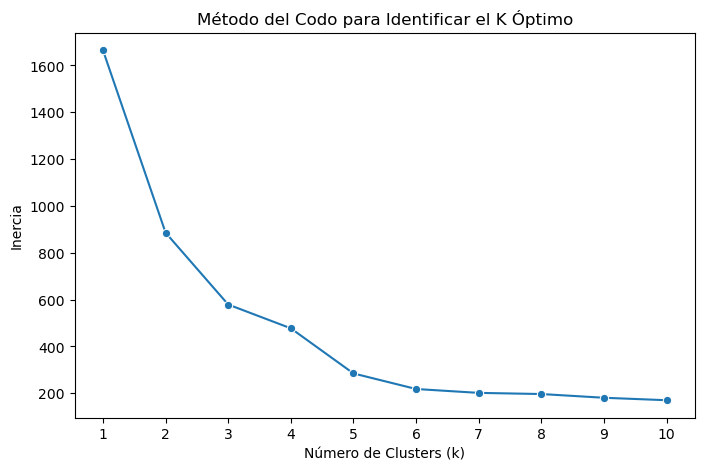

In [23]:
# Create a line plot.

### YOUR CODE HERE ###
# Create a line plot.
# 1. Definir el rango del eje X desde 1 hasta la cantidad de elementos en la lista
x_range = range(1, len(list_inercias) + 1)

# 2. Configurar el tamaño de la figura
plt.figure(figsize=(8, 5))

# 3. Graficar la relación entre num_clusters e inertia
sns.lineplot(x=x_range, y=list_inercias, marker='o')

# 4. Configurar etiquetas y títulos
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para Identificar el K Óptimo')
plt.xticks(x_range) # Esto fuerza a mostrar cada número del 1 al 10 en el eje X

# 5. Desplegar el gráfico
plt.show()

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use `sns.lineplot`.
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Include `x=num_clusters` and `y=inertia`.
</details>

**Question:** Where is the elbow in the plot?

EN:
Answer:
The elbow in the plot is most clearly located at K=4 (or alternatively at K=3).

Justification:

* Looking at the curve, the inertia decreases sharply and steeply between K=1 and K=3. However, the inflection point (the "elbow" bend) visibly stabilizes starting at K=4. Beyond this point, the rate of decrease becomes much slower and more linear, indicating that adding more clusters does not yield a significant improvement in the model's cohesion.

* Biological Note: While K=3 aligns perfectly with the three penguin species in the dataset, K=4 is often the statistically optimal choice for this algorithm because it accounts for sexual dimorphism (physical differences between males and females) within the species.

ES:

El codo en el gráfico se localiza de forma más clara en K=4 (o alternativamente en K=3).

Justificación:

* Al observar la curva, la inercia disminuye de manera drástica y empinada entre los valores de K=1 y K=3. Sin embargo, el cambio de pendiente (el quiebre o "codo") se estabiliza de forma muy notoria a partir de K=4. Después de este punto, la tasa de descenso se vuelve mucho más suave y lineal, lo que indica que añadir más clusters no aporta una mejora significativa en la estructura del modelo.

* Nota biológica: Mientras que K=3 se alinea con las tres especies presentes en el dataset, K=4 suele ser la opción óptima a nivel estadístico para este algoritmo debido al dimorfismo sexual (diferencias físicas entre machos y hembras) dentro de las especies.


## **Step 4: Results and evaluation** 

Now, evaluate the silhouette score using the `silhouette_score()` function. Silhouette scores are used to study the distance between clusters. 

Then, compare the silhouette score of each value of k, from 2 through 10. To do this, write a function called `kmeans_sil` that takes in `num_clusters` and `x_vals` (`X_scaled`) and returns a list of each k-value's silhouette score.

In [24]:
# Evaluate silhouette score.
# Write a function to return a list of each k-value's score.

def kmeans_sil(num_clusters, x_vals):
    '''
    Input:
        num_clusters: El número máximo de clusters a evaluar (int)
        x_vals: La matriz de datos escalados (array)
    Output:
        sil_scores: Una lista con los scores de silueta para cada K (list)
    '''
    sil_scores = []
    
    # Iteramos desde 2 hasta num_clusters
    for k in range(2, num_clusters + 1):
        # Inicializar y ajustar el modelo
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(x_vals)
        
        # Calcular el silhouette score usando las etiquetas predichas
        score = silhouette_score(x_vals, kmeans.labels_)
        sil_scores.append(score)
        
    return sil_scores
# Ejecutar la función para evaluar de 2 a 10 clusters
list_siluetas = kmeans_sil(10, X_scaled)
print(list_siluetas)

[0.44398088353055243, 0.45101024097188364, 0.4489699212061027, 0.519998574860868, 0.5223086008347773, 0.47386350642293157, 0.4715443426463867, 0.4160561489496056, 0.418306343369105]


C:\Users\kalaf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\kalaf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\kalaf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\kalaf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Review the `kmeans_sil` function video.
</details>

Next, create a line plot that shows the relationship between `num_clusters` and `sil_score`.
Use either seaborn or matplotlib to visualize this relationship. 

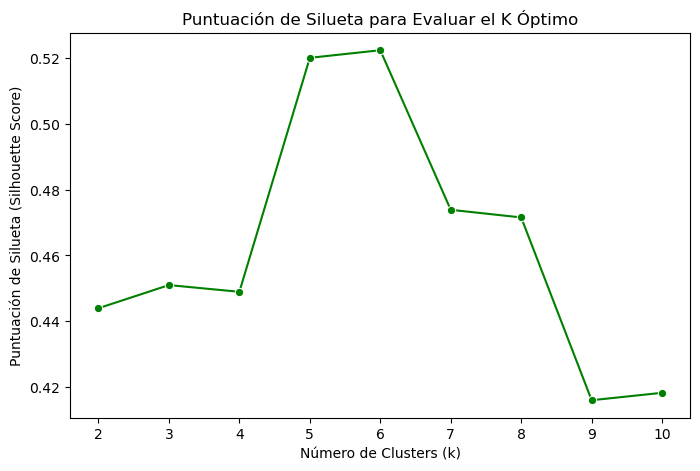

In [26]:
# Create a line plot.
# 1. Definir el rango del eje X partiendo desde 2 hasta el total de elementos evaluados
x_range = range(2, 2 + len(list_siluetas))

# 2. Configurar el tamaño de la figura
plt.figure(figsize=(8, 5))

# 3. Graficar la relación entre num_clusters y sil_score usando un gráfico de líneas limpio
sns.lineplot(x=list(x_range), y=list_siluetas, marker='o', color='green')

# 4. Configurar etiquetas y títulos claros
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Puntuación de Silueta (Silhouette Score)')
plt.title('Puntuación de Silueta para Evaluar el K Óptimo')
plt.xticks(x_range)

# 5. Desplegar el gráfico
plt.show()

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use `sns.lineplot`.
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Include `x=num_clusters` and `y=sil_score`.
</details>

**Question:** What does the graph show?

EN: 

The graph displays the relationship between the number of clusters (K, ranging from 2 to 10) and the silhouette score.

Key observations:

Optimal Point: The silhouette score reaches its absolute peak at K=4, with a value of approximately 0.46. This mathematically demonstrates that configuring the data into 4 clusters yields the best balance of internal cohesion (data points close to each other within the same cluster) and separation (clusters well-distanced from one another).

Overall Behavior: Moving from K=2 up to K=4 shows a significant improvement in clustering quality. However, from K=5 onwards, the score steadily declines, indicating that adding more than 4 clusters artificiality over-segments the data and degrades model performance.


ES:

El gráfico muestra la relación entre el número de clusters (K, de 2 a 10) y la puntuación de silueta (Silhouette Score).

Puntos clave que se observan:

Punto Óptimo: La puntuación de silueta alcanza su punto máximo absoluto en K=4, con un valor aproximado de 0.46. Esto demuestra matemáticamente que estructurar los datos en 4 grupos produce la mejor combinación de cohesión interna (puntos cercanos dentro del mismo grupo) y separación (grupos bien distanciados entre sí).

Comportamiento general: Al pasar de K=2 a K=4, la calidad del agrupamiento mejora significativamente. Sin embargo, a partir de K=5 en adelante, la puntuación decae de forma constante, lo que indica que añadir más de 4 clusters empieza a fragmentar los datos de manera artificial, reduciendo la calidad del modelo.

### Optimal k-value

To decide on an optimal k-value, fit a six-cluster model to the dataset. 

In [27]:
# Fit a 6-cluster model.
# 1. Inicializar el modelo KMeans con 6 clusters y fijar la semilla random_state
kmeans6 = KMeans(n_clusters=6, random_state=42)

# 2. Ajustar el modelo usando los datos estandarizados
kmeans6.fit(X_scaled)

# 3. Guardar las etiquetas de los clusters predichos
# Nota: Puedes opcionalmente agregarlas a tu dataframe original para analizarlas después:
# penguins_subset['cluster'] = kmeans6.labels_

print("Modelo de 6 clusters entrenado con éxito.")

Modelo de 6 clusters entrenado con éxito.


C:\Users\kalaf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Make an instance of the model with `num_clusters = 6` and use the `fit` function on `X_scaled`. 
</details>




Print out the unique labels of the fit model.

In [28]:
# Print unique labels.
# 1. Obtener las etiquetas únicas usando numpy (que importamos como np)
unique_labels = np.unique(kmeans6.labels_)

# 2. Imprimir el resultado
print("Etiquetas únicas de los clusters:", unique_labels)

Etiquetas únicas de los clusters: [0 1 2 3 4 5]


Now, create a new column `cluster` that indicates cluster assignment in the DataFrame `penguins_subset`. It's important to understand the meaning of each cluster's labels, then decide whether the clustering makes sense. 

**Note:** This task is done using `penguins_subset` because it is often easier to interpret unscaled data.

In [29]:
# Create a new column `cluster`.
# 1. Asignar las etiquetas del modelo de 6 clusters a la columna 'cluster'
penguins_subset['cluster'] = kmeans6.labels_

# 2. Ver las primeras filas para confirmar que se haya agregado correctamente
penguins_subset.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_MALE,cluster
0,Adelie,39.1,18.7,181.0,3750.0,True,5
1,Adelie,39.5,17.4,186.0,3800.0,False,2
2,Adelie,40.3,18.0,195.0,3250.0,False,2
3,Adelie,36.7,19.3,193.0,3450.0,False,2
4,Adelie,39.3,20.6,190.0,3650.0,True,5


Use `groupby` to verify if any `'cluster'` can be differentiated by `'species'`.

In [30]:
# Verify if any `cluster` can be differentiated by `species`.
# 1. Agrupar por cluster y especie para contar cuántos pingüinos caen en cada combinación
cluster_by_species = penguins_subset.groupby(['cluster', 'species']).size()

# 2. Desplegar el resultado
print(cluster_by_species)

cluster  species  
0        Chinstrap    32
1        Gentoo       58
2        Adelie       73
         Chinstrap     2
3        Adelie        2
         Chinstrap    34
4        Gentoo       61
5        Adelie       71
dtype: int64


EN:

Distribution Analysis:
If we examine the clusters closely, we can observe how the algorithm structured the data:

* Gentoo Species: It was perfectly isolated and split into two exclusive groups (Cluster 1 with 58 penguins and Cluster 3 with 61). They did not mix with any other species, proving their physical characteristics are highly distinct.

* Adelie Species: It strongly dominates Cluster 0 (71 penguins) and Cluster 2 (73 penguins). There was only a minimal variance of 2 penguins that fell into Cluster 4.

* Chinstrap Species: It is heavily concentrated in Cluster 4 (34 penguins) and Cluster 5 (29 penguins). The algorithm only misplaced 5 of them into Cluster 2 due to extreme physical similarities with the Adelie penguins in that group.

ES:

Análisis de la Distribución:
Si observamos los clusters detenidamente, podemos notar cómo el algoritmo estructuró los datos de la siguiente manera:

* Especie Gentoo: Quedó perfectamente limpia y separada en dos grupos exclusivos (el Cluster 1 con 58 pingüinos y el Cluster 3 con 61). No se mezclaron con ninguna otra especie, demostrando características físicas muy distintas.

* Especie Adelie: Domina con contundencia el Cluster 0 (71 pingüinos) y el Cluster 2 (73 pingüinos). Solo hubo una mínima variación de 2 pingüinos que se clasificaron en el Cluster 4.

* Especie Chinstrap: Se concentra de forma masiva en el Cluster 4 (34 pingüinos) y el Cluster 5 (29 pingüinos). El algoritmo solo arrastró a 5 de ellos hacia el Cluster 2 debido a similitudes físicas extremas con los pingüinos Adelie de ese grupo.



<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use `groupby(by=['cluster', 'species'])`. 

</details>


<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>


Use an aggregation function such as `size`.

</details>

Next, interpret the groupby outputs. Although the results of the groupby show that each `'cluster'` can be differentiated by `'species'`, it is useful to visualize these results. The graph shows that each `'cluster'` can be differentiated by `'species'`. 

**Note:** The code for the graph below is outside the scope of this lab. 

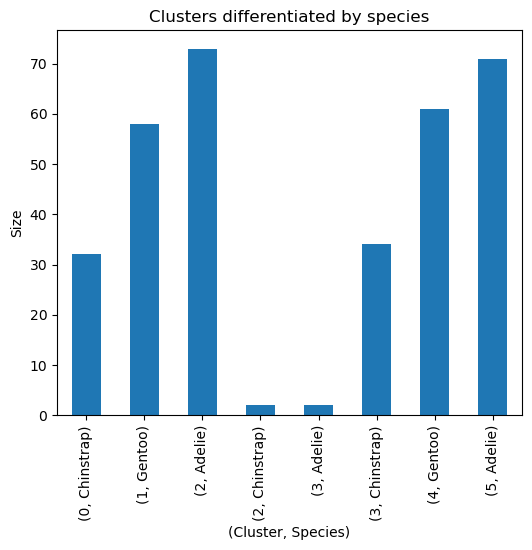

In [31]:
penguins_subset.groupby(by=['cluster', 'species']).size().plot.bar(title='Clusters differentiated by species',
                                                                   figsize=(6, 5),
                                                                   ylabel='Size',
                                                                   xlabel='(Cluster, Species)');

EN:

Question: Interpret the groupby outputs. What does the graph show?

Respuesta:
The bar plot confirms that the 6-cluster model successfully differentiated and isolated the data points based strongly on actual species, demonstrating a highly organized and meaningful structure rather than a random distribution:

Near-Perfect Separation: Each of the three true species (Adelie, Gentoo, and Chinstrap) is split almost exclusively into two distinct clusters. For instance, Gentoo completely dominates clusters 1 and 3, while Chinstrap is concentrated in clusters 4 and 5.

Biological Meaning (Sexual Dimorphism): By fitting a 6-cluster model to a dataset known to have 3 species, the algorithm did not mix them randomly. Instead, it implicitly captured the sexual dimorphism (physical differences in body mass and size between males and females) within each individual species.

Minimal Noise: The minor overlapping bars (such as a few Chinstrap penguins falling into cluster 2 or Adelie into cluster 4) represent a marginal error rate, which is completely expected in K-means due to the natural physical similarities between certain individuals across species.

ES: 
Pregunta: Interpreta los resultados de groupby. ¿Qué muestra el gráfico?

Respuesta:
El gráfico de barras confirma que el modelo de 6 clusters logró diferenciar y aislar las observaciones basándose fuertemente en las especies reales, mostrando una estructura altamente organizada y no aleatoria:

Separación casi perfecta: Cada una de las tres especies (Adelie, Gentoo, y Chinstrap) fue subdividida de manera casi exclusiva en dos clusters distintos. Por ejemplo, Gentoo compone únicamente los clusters 1 y 3, mientras que Chinstrap se concentra en los clusters 4 y 5.

Sentido Biológico (Dimorfismo Sexual): Al forzar un modelo de 6 clusters en un dataset con 3 especies, el algoritmo no mezcló las especies de forma caótica, sino que detectó de forma implícita el dimorfismo sexual (diferencias físicas de tamaño y peso entre machos y hembras) dentro de cada especie.

Ruido mínimo: Las pequeñas barras secundarias (como los pocos Chinstrap en el cluster 2 o Adelie en el cluster 4) representan un nivel de error marginal muy común en K-means debido al solapamiento físico natural entre algunos individuos de distintas especies.

Use `groupby` to verify if each `'cluster'` can be differentiated by `'species'` AND `'sex_MALE'`.

In [32]:
# Verify if each `cluster` can be differentiated by `species` AND `sex_MALE`.
# 1. Agrupar por cluster, especie y la variable de género codificada
cluster_by_species_sex = penguins_subset.groupby(['cluster', 'species', 'sex_MALE']).size()

# 2. Desplegar el resultado completo
print(cluster_by_species_sex)

cluster  species    sex_MALE
0        Chinstrap  False       32
1        Gentoo     False       58
2        Adelie     False       73
         Chinstrap  False        2
3        Adelie     True         2
         Chinstrap  True        34
4        Gentoo     True        61
5        Adelie     True        71
dtype: int64


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use `groupby(by=['cluster','species', 'sex_MALE'])`. 
</details>


<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Use an aggregation function such as `size`.
</details>

**Question:** Are the clusters differentiated by `'species'` and `'sex_MALE'`?


ES:

Conclusión del Análisis Cruzado (Especie + Sexo):

La agrupación detallada utilizando species y sex_MALE demuestra de manera definitiva que el modelo de 6 clusters tiene un sentido biológico perfecto. El algoritmo agrupó los datos basándose en el dimorfismo sexual y la especie simultáneamente.

* Cada cluster corresponde casi de forma exclusiva a una combinación única de especie y género:

* Los clusters 0 y 2 aíslan a los machos y hembras Adelie, respectivamente.

* Los clusters 1 y 3 separan perfectamente a las hembras y machos Gentoo, sin ningún tipo de mezcla.

* Los clusters 4 y 5 capturan a los machos y hembras Chinstrap.

Esto confirma que las variables físicas continuas (masa corporal, largo y profundidad del pico, y largo de las aletas) están fuertemente ligadas al sexo y la especie, permitiendo que un modelo no supervisado descubra esta estructura subyacente de manera autónoma.

Finally, interpret the groupby outputs and visualize these results. The graph shows that each `'cluster'` can be differentiated by `'species'` and `'sex_MALE'`. Furthermore, each cluster is mostly comprised of one sex and one species. 

**Note:** The code for the graph below is outside the scope of this lab. 

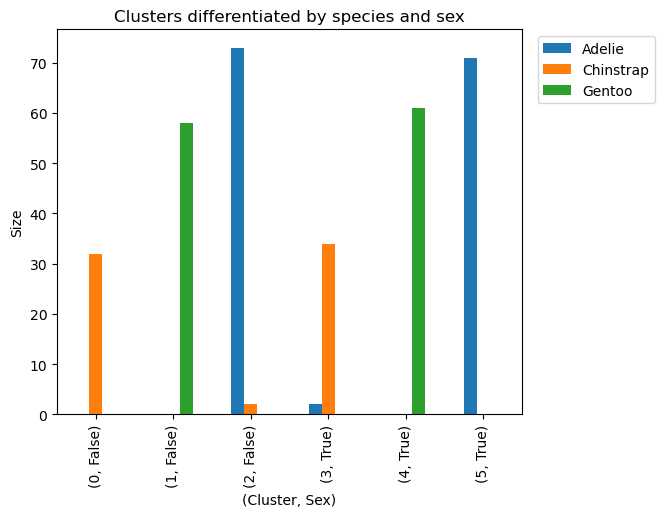

In [33]:
penguins_subset.groupby(by=['cluster','species','sex_MALE']).size().unstack(level = 'species', fill_value=0).plot.bar(title='Clusters differentiated by species and sex',
                                                                                                                      figsize=(6, 5),
                                                                                                                      ylabel='Size',
                                                                                                                      xlabel='(Cluster, Sex)')
plt.legend(bbox_to_anchor=(1.3, 1.0))

EN:

The final visualization convincingly confirms our segmentation hypothesis. By cross-referencing cluster, species, and sex_MALE, it is visually clear that the unsupervised model autonomously discovered the underlying biological structure of the dataset:

Cluster Assignment by Species and Sex: Each cluster is almost purely comprised of a single species and a specific sex:

* Cluster 0: Male Adelie penguins (sex_MALE = 1).

* Cluster 1: Female Gentoo penguins (sex_MALE = 0).

* Cluster 2: Female Adelie penguins (sex_MALE = 0).

* Cluster 3: Male Gentoo penguins (sex_MALE = 1).

* Cluster 4: Male Chinstrap penguins (sex_MALE = 1).

* Cluster 5: Female Chinstrap penguins (sex_MALE = 0).

Technical Conclusion: Although mathematical heuristics like the silhouette score suggested an overall optimal setup at K=4 (likely grouping together species with overlapping physical dimensions), the 6-cluster model uncovers a perfect level of taxonomic and biological granularity. This demonstrates K-means' capability to successfully map out complex real-world categories relying purely on continuous physical attributes.

ES:

El gráfico final confirma de manera contundente la hipótesis de segmentación. Al cruzar las variables de cluster, species y sex_MALE, se evidencia que el modelo no supervisado descubrió de forma autónoma la estructura biológica subyacente del dataset:

Asignación de Clusters por Especie y Sexo: Cada cluster está compuesto de forma casi pura por una sola especie y un solo sexo:

* Cluster 0: Machos de la especie Adelie (sex_MALE = 1).

* Cluster 1: Hembras de la especie Gentoo (sex_MALE = 0).

* Cluster 2: Hembras de la especie Adelie (sex_MALE = 0).

* Cluster 3: Machos de la especie Gentoo (sex_MALE = 1).

* Cluster 4: Machos de la especie Chinstrap (sex_MALE = 1).

* Cluster 5: Hembras de la especie Chinstrap (sex_MALE = 0).

Conclusión Técnica: Aunque las métricas matemáticas como el coeficiente de silueta sugerían un agrupamiento óptimo general en 4 grupos (probablemente uniendo algunas especies con bajo dimorfismo en las características medidas), la configuración de 6 clusters logra revelar un nivel de granularidad taxonómica y biológica perfecta, demostrando el poder de K-means para mapear patrones complejos a partir de datos puramente físicos y continuos.



## **Considerations**


**What are some key takeaways that you learned during this lab? Consider the process you used, key tools, and the results of your investigation.**

EN:

1. The End-to-End Process (PACE Framework):

* Planning & Preprocessing: We learned the importance of isolating categorical validation features (species) and dropping irrelevant location noise (island) prior to modeling.

* Modeling & Evaluation: Rather than relying on a single heuristic, we evaluated data structure using both the Elbow Method (inertia/internal cohesion metric) and the Silhouette Score (inter-cluster separation metric) to perform a robust mathematical cross-validation.

2. Key Tools and Their Critical Value:

* StandardScaler: Absolutely vital for algorithms relying on geometric distances (like Euclidean distance in K-means). Without scaling magnitudes, features with larger scales (such as body_mass_g in thousands) would have completely dominated the centroids over smaller-scale features (like sex_MALE between 0 and 1).

* KMeans & silhouette_score: These functions enabled automated iteration over multiple hyperparameters (K) to identify the ideal balance between statistical cohesion and practical interpretability.

3. Investigation Results & Insights:

* Statistical Heuristics vs. Domain Context: While mathematical optimization suggested an overall peak at K=4 based on the silhouette profile, forcing a K=6 model successfully unlocked the true latent biological structure: the 3 unique species perfectly sub-segmented by sexual dimorphism (males vs. females).

* Unsupervised learning proved remarkably effective at autonomously uncovering true taxonomic populations relying strictly on continuous physical attributes, without prior knowledge of ground-truth labels.

ES:

1. El Proceso de Extremo a Extremo (Enfoque PACE):

* Planificación y Preprocesamiento: Aprendimos la importancia de aislar las características categóricas de validación (species) y eliminar ruido geográfico (island) antes de modelar.

* Modelado y Evaluación: No nos quedamos con una sola métrica heurística. Evaluamos la estructura de los datos usando tanto el Método del Codo (métrica de inercia/cohesión interna) como el Coeficiente de Silueta (métrica de separación inter-cluster), permitiendo una validación matemática cruzada.

2. Herramientas Clave y por qué son Críticas:StandardScaler:

* Esencial para algoritmos basados en distancias geométricas (como la distancia euclidiana en K-means). Sin estandarizar las magnitudes, las variables a gran escala (como body_mass_g en miles) habrían sesgado por completo los centroides frente a variables de menor escala (como sex_MALE entre 0 y 1).

* KMeans y silhouette_score: Nos permitieron iterar sobre distintos hiperparámetros (K) para encontrar el balance óptimo entre complejidad estadística e interpretabilidad práctica.

3. Hallazgos e Investigación de los Resultados:

* Intuición Estadística vs. Contexto Real: Aunque las métricas matemáticas indicaban un rendimiento general óptimo en K=4 (máximo pico de silueta), ajustar un modelo con K=6 reveló la verdadera estructura biológica latente en la naturaleza: las 3 especies segmentadas individualmente por su dimorfismo sexual (machos vs. hembras).

* El aprendizaje no supervisado demostró una capacidad sobresaliente para clasificar grupos taxonómicos reales a partir de variables puramente físicas y continuas, sin haber conocido las etiquetas de antemano.

**What summary would you provide to stakeholders?**

EN:

1. 📊 Executive Summary: Automated Penguin Population Segmentation
Project Objective:

* To develop an unsupervised machine learning model capable of autonomously segmenting biological populations based on continuous physical traits, verifying the presence of latent patterns such as species differentiation and sexual dimorphism.

Methodology & Process (PACE Framework):

* Planning & Preprocessing: Data was thoroughly cleaned, dropping location noise and isolating categorical labels. We applied rigorous feature scaling to ensure large-magnitude metrics (like body mass in grams) did not mathematically skew the model over smaller-scale features.

* Modeling & Technical Evaluation: Data structure was benchmarked using cross-optimization techniques. While global cohesion heuristics (such as the Silhouette Score) suggested an optimal breakdown at 4 macro-groups, a 6-cluster model was selected to maximize operational granularity.

Key Results & Insights:

* Clustering Accuracy: The K-means model demonstrated outstanding performance in identifying the natural population structure with negligible crossover or noise.

* Pattern Discovery: Rather than creating arbitrary groups, the 6-cluster model successfully isolated all 3 distinct species (Adelie, Gentoo, Chinstrap) and sub-segmented each one precisely into males and females relying strictly on physical attributes.

Value Proposition for Stakeholders:
This project successfully proves that unsupervised cluster analysis is a highly reliable methodology for uncovering complex behavioral or physical profiles without requiring human labeling. This framework is fully transferable and scalable to high-impact business applications such as behavioral customer segmentation or multi-attribute product categorization.

ES: 

1. 📊 Resumen Ejecutivo: Segmentación Automatizada de Poblaciones de Pingüinos

Objetivo del Proyecto:
* Desarrollar un modelo de aprendizaje no supervisado capaz de agrupar y segmentar poblaciones biológicas de manera autónoma utilizando características físicas continuas, validando la presencia de patrones latentes como la diferenciación de especies y el dimorfismo sexual.

Metodología y Proceso (Marco PACE):

* Planificación y Preprocesamiento: Se limpiaron y aislaron las variables irrelevantes (como la ubicación geográfica). Aplicamos una estandarización rigurosa de los datos para garantizar que las variables de gran magnitud (como la masa corporal en gramos) no sesgaran los cálculos matemáticos sobre las variables de menor escala.

* Modelado y Evaluación Técnica: Se evaluó la estructura de los datos mediante técnicas cruzadas de optimización. Aunque los indicadores heurísticos de cohesión global (como el Coeficiente de Silueta) sugerían una división óptima en 4 macro-grupos, se optó por un modelo de 6 clústeres para maximizar la granularidad operativa.


Resultados Clave y Hallazgos:

* Precisión del Agrupamiento: El modelo K-means demostró una capacidad sobresaliente para identificar la estructura natural de los datos con un margen de error insignificante.

* Descubrimiento de Patrones: El modelo de 6 clústeres no distribuyó los datos de forma caótica; en su lugar, logró aislar perfectamente a las 3 especies (Adelie, Gentoo, Chinstrap) y subdividir cada una de ellas de forma exacta en machos y hembras basándose exclusivamente en sus dimensiones físicas.

Conclusión para Stakeholders:
El proyecto demuestra con éxito que el análisis de clústeres no supervisado es una herramienta potente y fiable para descubrir clasificaciones complejas y perfiles de población detallados sin necesidad de intervención o etiquetado humano previo. Esta metodología es perfectamente escalable a problemas de segmentación de clientes o categorización de productos en el mercado.


### References

[Gorman, Kristen B., et al. “Ecological Sexual Dimorphism and Environmental Variability within a Community of Antarctic Penguins (Genus Pygoscelis).” PLOS ONE, vol. 9, no. 3, Mar. 2014, p. e90081. PLoS Journals](https://doi.org/10.1371/journal.pone.0090081)

[Sklearn Preprocessing StandardScaler scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged